<!-- HTML file automatically generated from DocOnce source (https://github.com/doconce/doconce/)
doconce format html hw5.do.txt --no_mako -->
<!-- dom:TITLE: PHY321: Classical Mechanics 1 -->

# Homework 5 (Due 13 Mar)

#### Names of Collaborators - Abhishek Vilekar, Matrim Cirullo-Nesbitt, Andrew Gabaldon

## Exercise 3 (15pt), Another 1-D conservative system; baby bifurcations
* 3d (5pt) Plot the potential energy for two different values of $m/M$ and explain the differences in the potential energy graphs. Consider cases when you observe very different motion. Think about an initial condition where the mass $m$ is at rest and the wheel is at rest. What happens when you release the mass $m$ for your two cases?

In [35]:
import numpy as np
from math import *
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline
plt.style.use('seaborn-v0_8-colorblind')

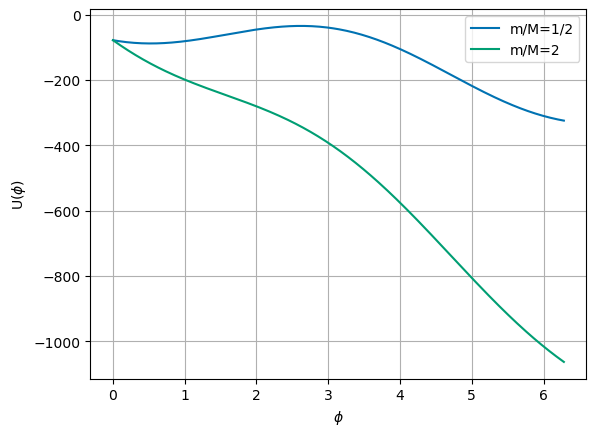

In [36]:
g = 9.8
R = 2
phi = np.linspace(0,2*np.pi,300)
M = 4
m = 2
m2 = 8

U = -g*R*(M*np.cos(phi) + m*phi)
U2 = -g*R*(M*np.cos(phi) + m2*phi)
plt.plot(phi, U, label='m/M=1/2')
plt.plot(phi, U2, label='m/M=2')
plt.legend()
plt.xlabel('$\phi$')
plt.ylabel('U($\phi$)')
plt.grid()
plt.show()


**We can observe that the plot with m/M=1/2 has a local maxima and minima at points where we see the gradient of the curve equals 0. This shows the existence of critical points. However, the plot with m/M=2 is continously decreasing with no points where the gradient is 0. If we release mass m from rest in the case where m/M=1/2, the system oscillates around the stable critical point. However, if we release mass m where m/M = 2, there are no fixed points to oscillate around so the mass m loops around the circle and falls with mass M.**

## Exercise 4 (20 pt), Phase Diagrams

One of the most useful tools we can learn from classical mechanics is the phase diagram. For us, it is the plot of the position and velocity of a particle in a 1D system, but the concept can be extended to higher dimensions and to other systems. The phase diagram can tell us about the stability of fixed points, the period of oscillations, and the qualitative behavior of the system. 

In this exercise, we will consider a particle in a potential $U(x)$ and we will plot the phase diagrams using both `quiver` and `streamplot` in `matplotlib`. The purpose of this exercise is to learn how to plot phase diagrams and to interpret the results.

We start with a little code for plotting the phase diagram of the simple harmonic oscillator. The code is written in a way that you can easily modify it to plot the phase diagram of other systems. The key point is to make sure that the `quiver` or `streamplot` function is called with the correct arguments. 


In [37]:
def SHO(X,V):
    
    # For a simple harmonic oscillator, x' = v, and v' = -x.
    dX = V
    dV = -X
    
    return dX, dV

def generate_phase_space(x_lim, v_lim, grid_size):

    x = np.linspace(x_lim[0], x_lim[1], grid_size)
    v = np.linspace(v_lim[0], v_lim[1], grid_size)
    
    X, V = np.meshgrid(x, v)
    
    dX, dV = SHO(X, V)
    
    return X, V, dX, dV

# Generate phase space
x_lim = (-5, 5)
v_lim = (-5, 5)
grid_size = 20
X, V, dX, dV = generate_phase_space(x_lim, v_lim, grid_size)

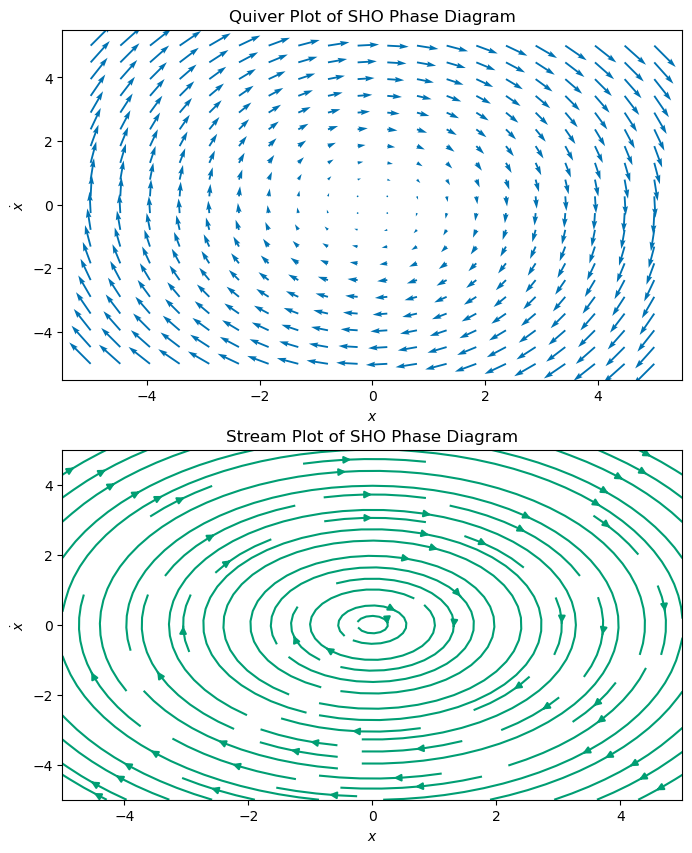

In [38]:
fig, axs = plt.subplots(2, 1, figsize=(8, 10))  # Two rows, one column
    
# Quiver plot on the first subplot
axs[0].quiver(X, V, dX, dV, color='C0')
axs[0].set_title('Quiver Plot of SHO Phase Diagram')
axs[0].set_xlabel(r'$x$')
axs[0].set_ylabel(r'$\dot{x}$')

# Stream plot on the second subplot
axs[1].streamplot(X, V, dX, dV, color='C1')
axs[1].set_title('Stream Plot of SHO Phase Diagram')
axs[1].set_xlabel(r'$x$')
axs[1].set_ylabel(r'$\dot{x}$');

* 4a (2pt) Explain how the code works to produce the phase diagram. The key part is explaining what the function `SHO` does and how that relates to the `quiver` and `streamplot` calls. What does `np.meshgrid` do and why is it used?

**The function SHO defines the differential equations of the simple harmonic system v = dx/dt and dv/dt = -x. The spring constant is set to 1. The quiver command plots at the x, v point the respective gradient at that specific point with the direction showing the change in x,v. In this case, dx/dt = v and dv/dt =-x. The streamplot command creates lines that follows the direction of the gradients to show the flow of the vector field. The np.meshgrid creates a rectangular grid of points based on the input arrays x, v. This is used so the gradient can be calculated for every point in the grid.**

We have discussed the physical pendulum in class where the potential energy is given by:

$$U(\theta)=mgl(1-\cos\theta)$$

* 4b (4pt) Modify the code to produce the phase diagram for the physical pendulum. You can choose mass and length. Make sure to explore the diagram outside of the small angle approximation. What new features do you observe in the phase diagram? What motion are they associated with?

$$
F(\theta) = -\frac{dU(\theta)}{d\theta} = -mg\sin(\theta)
$$

$$
mL\frac{d^2\theta}{dt^2} = -mg\sin(\theta)
$$

$$
\frac{d^2\theta}{dt^2} = -\frac{g}{L}\sin(\theta)
$$

In [39]:
def SHO_pend(theta,V):
    g = 9.8
    dtheta = V     #The ODEs of the physical pendulum are: v = dtheta/dt , dv/dt = -(g/L) sin(theta) where L is length
    dV = -(g/3) * np.sin(theta)   #Chose length of pendulum to be 3m
    
    return dX, dV

def generate_phase_space_pend(x_lim, v_lim, grid_size):

    theta = np.linspace(x_lim[0], x_lim[1], grid_size)
    v = np.linspace(v_lim[0], v_lim[1], grid_size)
    
    theta, V = np.meshgrid(theta, v)
    
    dtheta, dV = SHO_pend(theta, V)
    
    return theta, V, dtheta, dV

# Generate phase space
x_lim = (-4*np.pi, 4*np.pi)
v_lim = (-20, 20)
grid_size = 20
theta, V1, dtheta, dV1 = generate_phase_space_pend(x_lim, v_lim, grid_size)

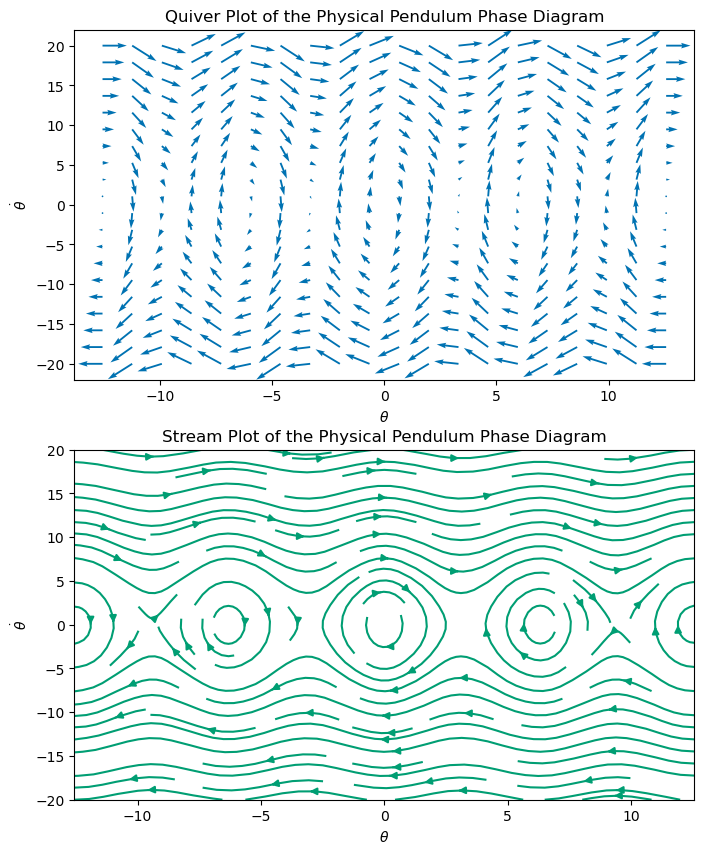

In [40]:
fig, axs = plt.subplots(2, 1, figsize=(8, 10))  # Two rows, one column
    
# Quiver plot on the first subplot
axs[0].quiver(theta, V1, dtheta, dV1, color='C0')
axs[0].set_title('Quiver Plot of the Physical Pendulum Phase Diagram')
axs[0].set_xlabel(r'$\theta$')
axs[0].set_ylabel(r'$\dot{\theta}$')

# Stream plot on the second subplot
axs[1].streamplot(theta, V1, dtheta, dV1, color='C1')
axs[1].set_title('Stream Plot of the Physical Pendulum Phase Diagram')
axs[1].set_xlabel(r'$\theta$')
axs[1].set_ylabel(r'$\dot{\theta}$');

**The physical pendulum's phase diagram has multiple critical points or points where the force is zero (or the derivative of the potential energy is zero). The plot shows a stable point at (0,0) where the flow of gradients of x,v revolve around. However unlike the SHO system, there are two unstable points on either end of the stable (0,0) point where the system is flowing away from that point.**



Now we have a code that we can use to plot the phase diagram of any 1D system. We will use it to explore the damped harmonic oscillator and the damped physical pendulum. Here we write the equations of motion as the system is still 1-D, but the forces are not derived from a potential.

The damped harmonic oscillator has the equation of motion:
$$\ddot{x}=-\frac{k}{m}x-\frac{b}{m}\dot{x}$$

* 4c (5pt) Modify the code to produce the phase diagram for the damped harmonic oscillator. You can choose $k/m$ and $b/m$, but might want to explore the values. What features do you observe in the phase diagram? What motion are they associated with?

In [41]:
def SHO_damped(X,V):
    dX = V
    dV = -4*X - 2*V   #k/m has been chosen to be 4. b/m is chosen to be 2

    return dX, dV

def generate_phase_space_damped(x_lim, v_lim, grid_size):

    x = np.linspace(x_lim[0], x_lim[1], grid_size)
    v = np.linspace(v_lim[0], v_lim[1], grid_size)
    
    X, V = np.meshgrid(x, v)
    
    dX, dV = SHO_damped(X, V)
    
    return X, V, dX, dV

# Generate phase space
x_lim = (-5, 5) 
v_lim = (-5, 5)
grid_size = 20
X_d, V_d, dX_d, dV_d = generate_phase_space_damped(x_lim, v_lim, grid_size)

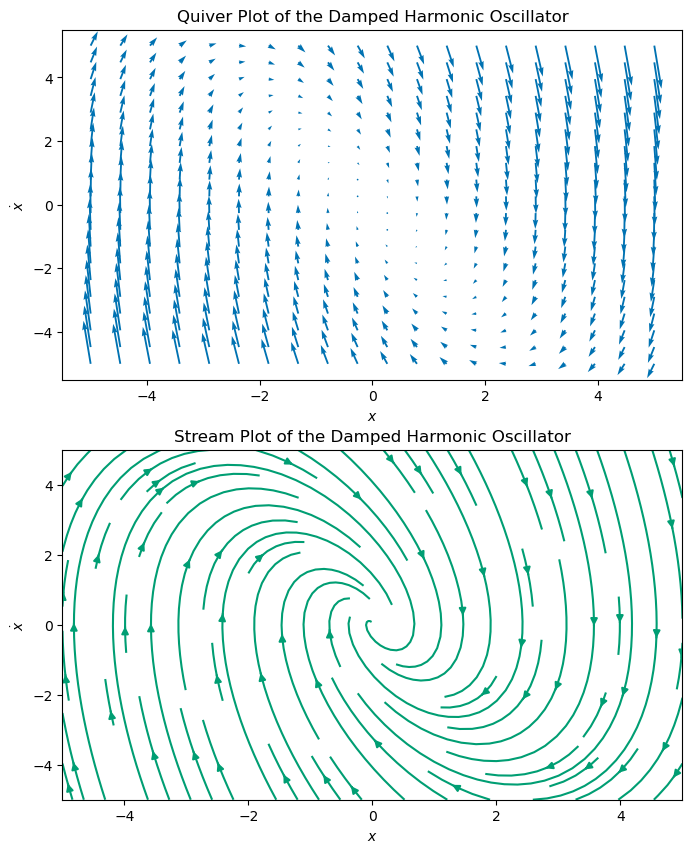

In [42]:
fig, axs = plt.subplots(2, 1, figsize=(8, 10))  # Two rows, one column
    
# Quiver plot on the first subplot
axs[0].quiver(X_d, V_d, dX_d, dV_d, color='C0')
axs[0].set_title('Quiver Plot of the Damped Harmonic Oscillator')
axs[0].set_xlabel(r'$x$')
axs[0].set_ylabel(r'$\dot{x}$')

# Stream plot on the second subplot
axs[1].streamplot(X_d, V_d, dX_d, dV_d, color='C1')
axs[1].set_title('Stream Plot of the Damped Harmonic Oscillator')
axs[1].set_xlabel(r'$x$')
axs[1].set_ylabel(r'$\dot{x}$');

**The phase diagram of the damped harmonic oscillator shows the same stable point (0,0) like the SHO plot. However, we can notice spirals in the system's flow. This means the system oscillates until it reaches the point (0,0) due to the energy loss of the damping. This is unlike the SHO phase diagram where the oscillation occurs around x=0 but never reaches it.**

**When the damping term b/m is much higher than k/m, the system rapidy approaches x=0.**

The damped physical pendulum has the equation of motion:
$$\ddot{\theta}=-\frac{g}{l}\sin\theta-\frac{b}{ml}\dot{\theta}$$

* 4d (5pt) Modify the code again to produce the phase diagram for the damped physical pendulum. You can choose $b/ml$, but might want to explore the values. How does this motion compare to the motion of the damped harmonic oscillator? 

In [43]:
def SHO_damped_pend(theta,V):
    g = 9.8
    dtheta = V     
    dV = -(g/1) * np.sin(theta) - 1*V  #The length l is 1 and b/ml was chosen to be 1
    
    return dX, dV

def generate_phase_space_damped_pend(x_lim, v_lim, grid_size):

    theta = np.linspace(x_lim[0], x_lim[1], grid_size)
    v = np.linspace(v_lim[0], v_lim[1], grid_size)
    
    theta, V = np.meshgrid(theta, v)
    
    dtheta, dV = SHO_damped_pend(theta, V)
    
    return theta, V, dtheta, dV

# Generate phase space
x_lim = (-4*np.pi, 4*np.pi)
v_lim = (-20, 20)
grid_size = 20
theta_dp, V_dp, dtheta_dp, dV_dp = generate_phase_space_damped_pend(x_lim, v_lim, grid_size)

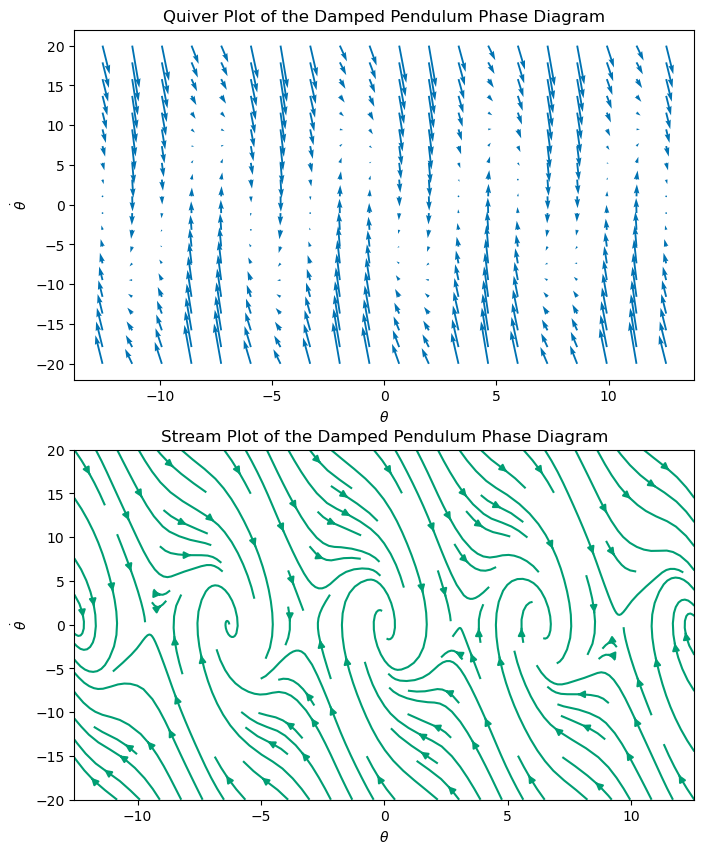

In [44]:
fig, axs = plt.subplots(2, 1, figsize=(8, 10))  # Two rows, one column
    
# Quiver plot on the first subplot
axs[0].quiver(theta_dp, V_dp, dtheta_dp, dV_dp, color='C0')
axs[0].set_title('Quiver Plot of the Damped Pendulum Phase Diagram')
axs[0].set_xlabel(r'$\theta$')
axs[0].set_ylabel(r'$\dot{\theta}$')

# Stream plot on the second subplot
axs[1].streamplot(theta_dp, V_dp, dtheta_dp, dV_dp, color='C1')
axs[1].set_title('Stream Plot of the Damped Pendulum Phase Diagram')
axs[1].set_xlabel(r'$\theta$')
axs[1].set_ylabel(r'$\dot{\theta}$')

plt.show()

**The phase diagram of a damped pendulum shows a stable point at (0,0) and the unstable points similar to the physical pendulum phase diagram. The system's flow is away from the unstable points and towards the stable point x=0. We  observe spirals where the damped oscillations with some initial x,v always lead to the point x=0 similar to the damped oscillator phase diagram. The system also spirals rapidly into x=0 when the damping term b/ml is much greater than g/l.**

* 4e (4pt) Return to the simple harmonic oscillator. Show using conservation of energy the phase diagram is a series of ellipses in $(x,v)$ space. Plot these ellipses on top of a phase diagram for the simple harmonic oscillator to illustrate how the phase diagram explains the total energy of the system.

**Written work on proof of ellipses in (x,v) using conservation of energy is attached.**

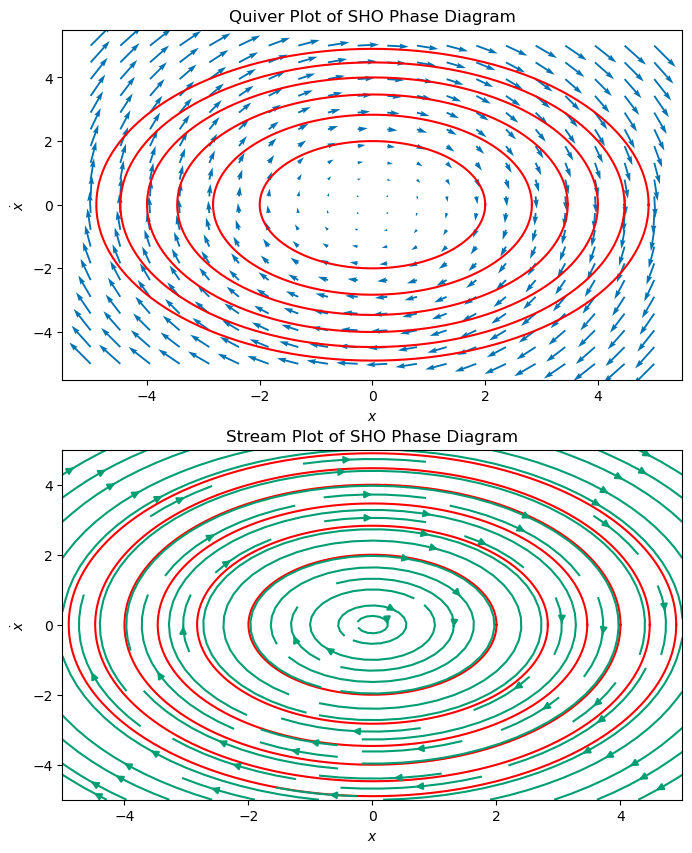

In [45]:
#Used the SHO phase diagram

fig, axs = plt.subplots(2, 1, figsize=(8, 10)) 

axs[0].quiver(X, V, dX, dV, color='C0')
axs[0].set_title('Quiver Plot of SHO Phase Diagram')
axs[0].set_xlabel(r'$x$')
axs[0].set_ylabel(r'$\dot{x}$')

#I set m and k to 1 for simplicity
theta = np.linspace(0, 2*np.pi, 300)
energy = [2, 4, 6, 8, 10, 12]  #These are example energies to calculate semi-major and minor axis distances
for E in energy:
    r = np.sqrt(2*E)  #Used parametric equations for the ellipse x=acos(t), y=bsin(t)
    x = r * np.cos(theta)
    v = r * np.sin(theta)
    axs[0].plot(x, v, color='red')

for E in energy:
    r = np.sqrt(2*E)
    x = r * np.cos(theta)
    v = r * np.sin(theta)
    axs[1].plot(x, v, color='red')

axs[1].streamplot(X, V, dX, dV, color='C1')
axs[1].set_title('Stream Plot of SHO Phase Diagram')
axs[1].set_xlabel(r'$x$')
axs[1].set_ylabel(r'$\dot{x}$')

plt.show()

**This shows that ellipses in the phase diagram correspond to different energies. The flow of the system from one (x,v) travels in one ellipse that does not intersect with other ellipses (that have different initial conditions for (x,v)) to conserve energy.**

## Excercise 5

We are given the IVP:
$$ \ddot{x} = -\omega^2 x, \quad x(0) = 1, \quad \dot{x}(0)=0$$

We are also given a function, `euler`, that solves the IVP using the Euler method, and a function, `euler_cromer`, that uses the Euler-Cromer method to solve the IVP. Both of these use a time step derived from the total number of integration steps $N$.

In [46]:
omega = 1  # Angular frequency
x0 = 1  # Initial position
v0 = 0  # Initial velocity
t0 = 0  # Start time
tf = 100  # End time
N = 10000  # Number of time steps
dt = (tf-t0)/N  # Time step

In [47]:
def euler(omega, x0, v0, t0, tf, dt):
    t = np.arange(t0, tf, dt)
    x = np.zeros(t.shape)
    v = np.zeros(t.shape)
    x[0], v[0] = x0, v0

    for i in range(1, len(t)):
        x[i] = x[i-1] + dt * v[i-1]
        v[i] = v[i-1] - dt * omega**2 * x[i-1]

    return t, x, v

def euler_cromer(omega, x0, v0, t0, tf, dt):
    t = np.arange(t0, tf, dt)
    x = np.zeros(t.shape)
    v = np.zeros(t.shape)
    x[0], v[0] = x0, v0

    for i in range(1, len(t)):
        v[i] = v[i-1] - dt * omega**2 * x[i-1]
        x[i] = x[i-1] + dt * v[i]

    return t, x, v

We then call these functions to plot the position and velocity w.r.t. time. We are given the code to store position and velocity in a pandas dataframe. We observe the systematic inaccuracy in the Euler method, with regards to energy conservation.

In [48]:
t, x, v = euler(omega, x0, v0, t0, tf, dt)
eulerdf = pd.DataFrame({'t': t, 'x': x, 'v': v})

t, x, v = euler_cromer(omega, x0, v0, t0, tf, dt)
euler_cromerdf = pd.DataFrame({'t': t, 'x': x, 'v': v})

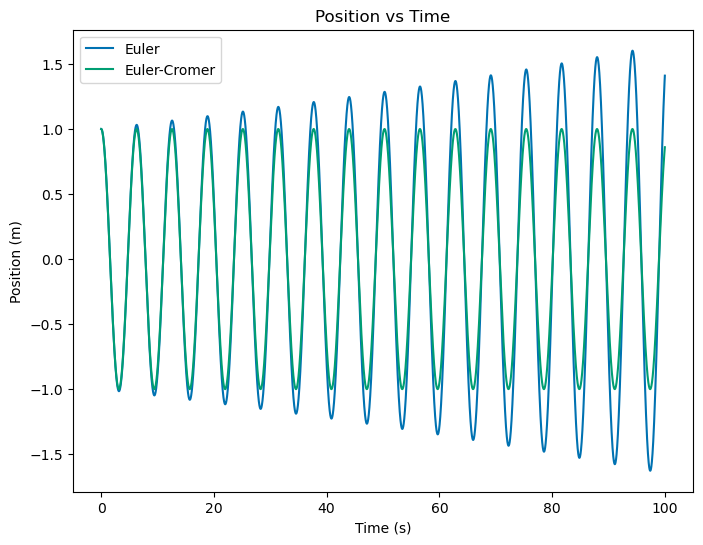

In [49]:
# plot all positions vs time on the same graph
plt.figure(figsize=(8, 6))
plt.plot(eulerdf['t'], eulerdf['x'], label='Euler')
plt.plot(euler_cromerdf['t'], euler_cromerdf['x'], label='Euler-Cromer')
plt.title('Position vs Time')
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.legend()
plt.show()

### 5a.
Graph the energy of the system as a function of time for both the Simple Euler and Euler-Cromer methods. You should use the same initial conditions and time step for both methods. What do you observe?

Recall that the energy of a system at any given time is equal to the kinetic energy plus potential energy at that point.
$$ E = K + U = \frac{1}{2}m\dot{x}(t)^2 + U(t) $$
The system is (should be) conservational, so
$$ F(x) = -\frac{\text{d}U}{\text{d}x} \Rightarrow -\int F(x) dx = U$$
$$-\int F(x) dx = -\int m\ddot{x}dx = \int m\omega^2 x dx = \frac{m\omega^2}{2}x^2+U_0$$
We take $U_0 = 0$, as is our right, thus,
$$ E = \frac{1}{2}m\dot{x}(t)^2 + \frac{m\omega^2}{2}x(t)^2$$
We assume a mass of $1$ kg.

We now define functions that take the positions, and velocities as inputs and output the kinetic and potential energies of the system. We also define a function that combines these two.

In [50]:
def KineticEnergy(vel_aray,m=1):
    K=np.zeros(vel_aray.shape)
    for i,j in enumerate(vel_aray):
        K[i] = (1/2) * m * j**2
    return K
def PotentialEnergy(pos_aray,m=1,omega=1):
    U = np.zeros(pos_aray.shape)
    for i,j in enumerate(pos_aray):
        U[i] = (1/2) * m * omega**2 * j**2
    return U
def TotEnergy(k_aray,u_aray):
    try:
        E = np.zeros(k_aray.shape)
        for i in range(len(k_aray)):
            E[i] = k_aray[i] + u_aray[i]
        return E
    except:
        print("An error has occurred! The potential and kinetic energy arrays do not have the same length!")
euler_k = KineticEnergy(eulerdf['v'])
euler_u = PotentialEnergy(eulerdf['x'],omega)
euler_e = TotEnergy(euler_k,euler_u)
e_cromer_k = KineticEnergy(euler_cromerdf['v'])
e_cromer_u = PotentialEnergy(euler_cromerdf['x'],omega)
e_cromer_e = TotEnergy(e_cromer_k,e_cromer_u)


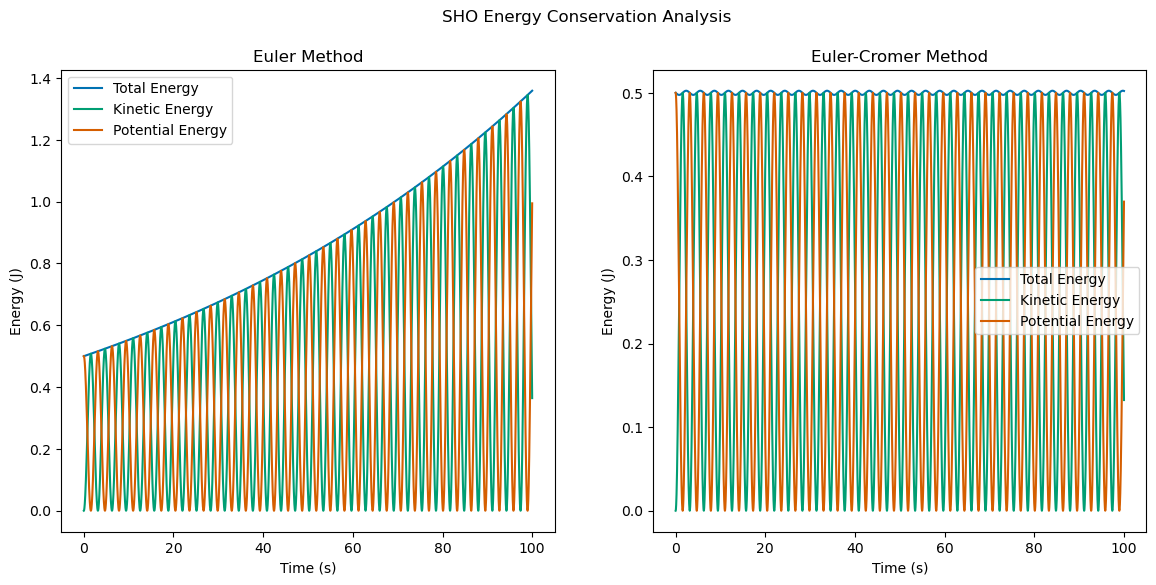

In [51]:
fig, ax = plt.subplots(1,2,figsize=(14,6))
plt.suptitle("SHO Energy Conservation Analysis")
ax[0].set_title("Euler Method")
ax[0].plot(eulerdf['t'],euler_e,label="Total Energy")
ax[0].plot(eulerdf['t'],euler_k, label="Kinetic Energy")
ax[0].plot(eulerdf['t'],euler_u, label ="Potential Energy")
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Energy (J)')
ax[0].legend()

ax[1].set_title("Euler-Cromer Method")
ax[1].plot(euler_cromerdf['t'],e_cromer_e,label="Total Energy")
ax[1].plot(euler_cromerdf['t'],e_cromer_k, label="Kinetic Energy")
ax[1].plot(euler_cromerdf['t'],e_cromer_u, label ="Potential Energy")
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Energy (J)')
ax[1].legend()

plt.show()

From the graphs, we see that in the Euler Method, the total energy steadily increases, whereas in the Euler-Cromer method, the total energy oscillates about $0.5$ J.

### 5b.
Write the exact solution for these initial conditions and compare the numerical solutions to the exact solution using a point-by-point measure. What do you observe? Come up with a measure of the overall error (or find one) in the numerical solution and discuss the results.

Recalling basic physics, the exact solution for these equations should be that the energy is constant for any time, $t$. We arrive to this by taking any extremum, say, $x = 1, \dot{x} = 0$. At this point,
$$E = K + U = \frac{1}{2}m\dot{x}^2 + \frac{1}{2}m\omega^2 x^2 = 0 + \frac{1}{2}m\omega^2\Rightarrow$$
$$\Rightarrow E = \frac{1}{2}\text{J}.$$
Since energy is conserved, The energy $\forall t$ is $E=\frac{1}{2}$ J.

We define a function that takes the energy of a numerical solution and outputs the relative error between it and the real solution at each point.

In [52]:
exact_energy = 0.5 #The constant energy of our analytical solution

def RelativeError(energy_aray,ref_energy=0):
    e_r = np.zeros(energy_aray.shape)
    for i,j in enumerate(energy_aray):
        e_r[i] = (abs(ref_energy - j) / ref_energy) * 100
    return e_r #returns relative error array in %

And we plot it for both numerical solutions.

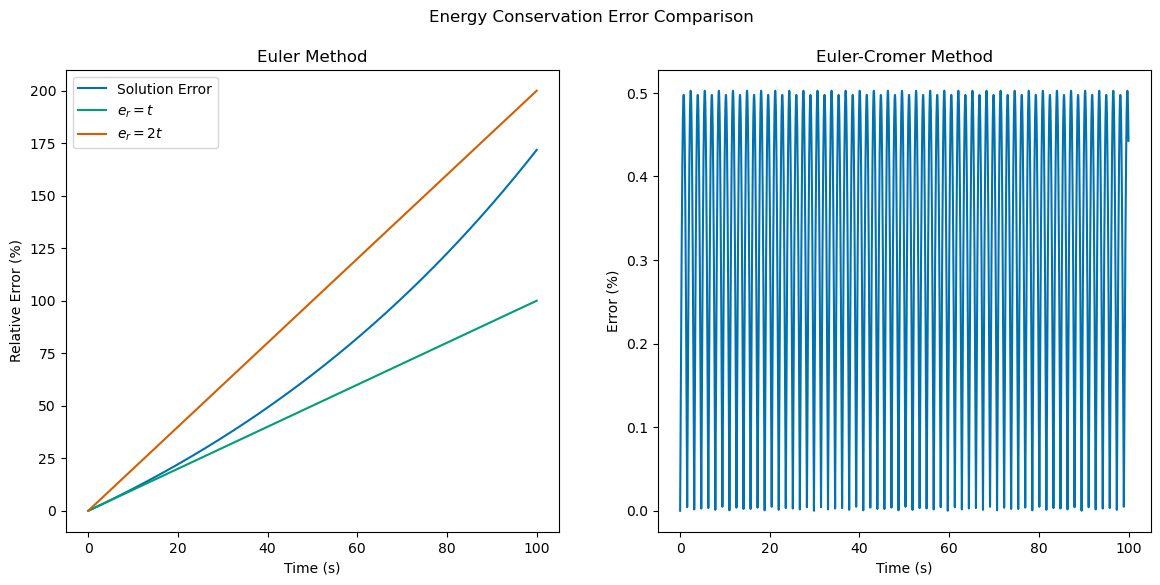

In [53]:
fig, ax = plt.subplots(1,2,figsize=(14,6))
plt.suptitle("Energy Conservation Error Comparison")

ax[0].plot(eulerdf['t'],RelativeError(euler_e,exact_energy),label="Solution Error")
ax[0].plot(eulerdf['t'],eulerdf['t'],label=r"$e_r = t$")
ax[0].plot(eulerdf['t'],2*eulerdf['t'],label=r"$e_r = 2t$")
ax[0].set_title("Euler Method")
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Relative Error (%)")
ax[0].legend()

ax[1].plot(euler_cromerdf['t'],RelativeError(e_cromer_e,exact_energy))
ax[1].set_title("Euler-Cromer Method")
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Error (%)")

plt.show()

We can see from the graph that as time increases, in the Euler Method case, the error seems to be greater than an error of $e_r = t\%$ at all points, and mostly, less than an error of $e_r = 2t\%$. In the case of Euler-Cromer, the error oscillates between $e_r = 0.5\%$, and $e_r = 0\%$.

### 5c.
Write the code to solve the simple harmonic oscillator with second-order Runge Kutta (this needs to be from scratch, not using a library). You can use the lecture notes as a starting point.

We look at the update equations for the Runge Kutta 2nd order integration method from the homework [website](https://dannycaballero.info/phy321msu/resources/integrators.html).

$$k_{1x} = v_{n-1}\Delta t$$
$$k_{1v} = -\omega^2x_{n-1}\Delta t$$
$$k_{2x} = (v_{n-1} + \frac{k_{1v}}{2})\Delta t$$
$$k_{2v} = -\omega^2(x_{n-1}+\frac{k_{1x}}{2})\Delta t$$
$$x_{n} = x_{n-1} + k_{2x}$$
$$v_{n} = v_{n-1} + k_{2v}$$

These are pretty self-explanatory, so without further ado, the implementation is below.

In [54]:
omega = 1  # Angular frequency
x0 = 1  # Initial position
v0 = 0  # Initial velocity
t0 = 0  # Start time
tf = 100  # End time
N = 10000  # Number of time steps
dt = (tf-t0)/N  # Time step
 #restatement of original variables.

def RungeKutta2(omega, x0, v0, t0, tf, dt):
    t = np.arange(t0, tf, dt)
    x = np.zeros(t.shape)
    v = np.zeros(t.shape)
    x[0], v[0] = x0, v0

    for i in range(1,len(t)):
        k_1x = v[i-1]*dt
        k_1v = -1 * omega**2 * x[i-1] * dt

        k_2x = (v[i-1] + k_1v) * dt
        k_2v = -1 * omega**2 * (x[i-1] + k_1x) * dt
        
        x[i] = x[i-1] + 0.5 * (k_1x + k_2x) #avg it
        v[i] = v[i-1] + 0.5 * (k_1v + k_2v) #avg it
    return t, x, v

In [55]:
t, x, v = RungeKutta2(omega, x0, v0, t0, tf, dt)
r_k2df = pd.DataFrame({'t': t, 'x': x, 'v': v})
r_k2df.head()

,t,x,v
0,0.00,1.00000,0.000000
1,0.01,0.99995,-0.010000
2,0.02,0.99980,-0.019999
3,0.03,0.99955,-0.029996
4,0.04,0.99920,-0.039990


We plot the data.

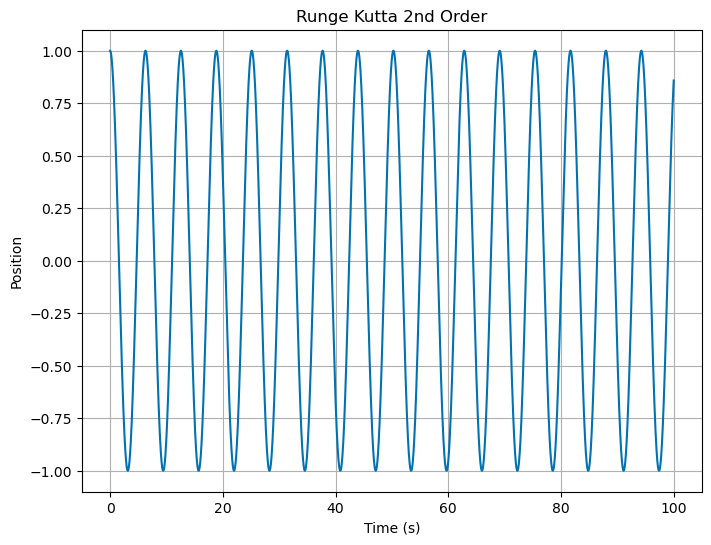

In [56]:

fig, ax = plt.subplots(1,1,figsize=(8,6))
ax.plot(r_k2df['t'],r_k2df['x'])
ax.set_title("Runge Kutta 2nd Order")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Position")
ax.grid()
plt.show()

### 5d.
Compare the results of this RK2 method to the previous methods. Use whatever comparison method you can develop or explain. Careful here because the time steps might not be the same for the different methods.

We use a similar comparison from 5b, as we used the same time step!

In [57]:

rk2_k, rk2_u = KineticEnergy(r_k2df['v']), PotentialEnergy(r_k2df['x'],omega=omega)
rk2_e = TotEnergy(rk2_k,rk2_u)

exact_energy=0.5 #J


Plot the energies:

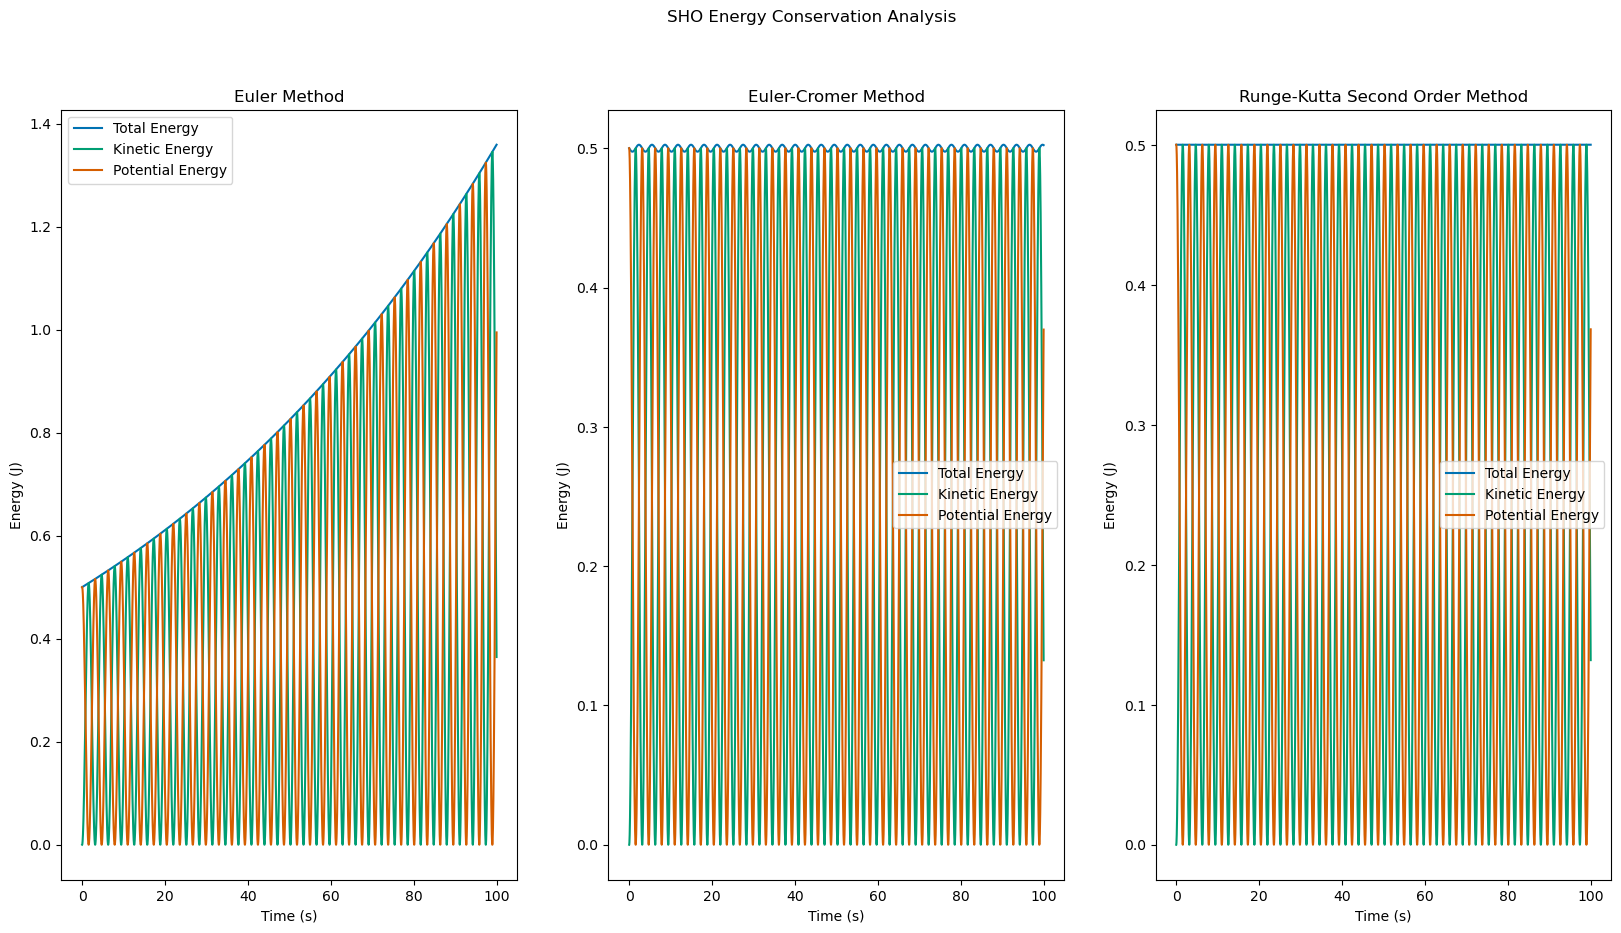

In [58]:
fig, ax = plt.subplots(1,3,figsize=(20,10))
plt.suptitle("SHO Energy Conservation Analysis")
ax[0].set_title("Euler Method")
ax[0].plot(eulerdf['t'],euler_e,label="Total Energy")
ax[0].plot(eulerdf['t'],euler_k, label="Kinetic Energy")
ax[0].plot(eulerdf['t'],euler_u, label ="Potential Energy")
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Energy (J)')
ax[0].legend()

ax[1].set_title("Euler-Cromer Method")
ax[1].plot(euler_cromerdf['t'],e_cromer_e,label="Total Energy")
ax[1].plot(euler_cromerdf['t'],e_cromer_k, label="Kinetic Energy")
ax[1].plot(euler_cromerdf['t'],e_cromer_u, label ="Potential Energy")
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Energy (J)')
ax[1].legend()

ax[2].set_title("Runge-Kutta Second Order Method")
ax[2].plot(r_k2df['t'],rk2_e,label="Total Energy")
ax[2].plot(r_k2df['t'],rk2_k, label="Kinetic Energy")
ax[2].plot(r_k2df['t'],rk2_u, label ="Potential Energy")
ax[2].set_xlabel('Time (s)')
ax[2].set_ylabel('Energy (J)')
ax[2].legend()

plt.show()

Plot the error:

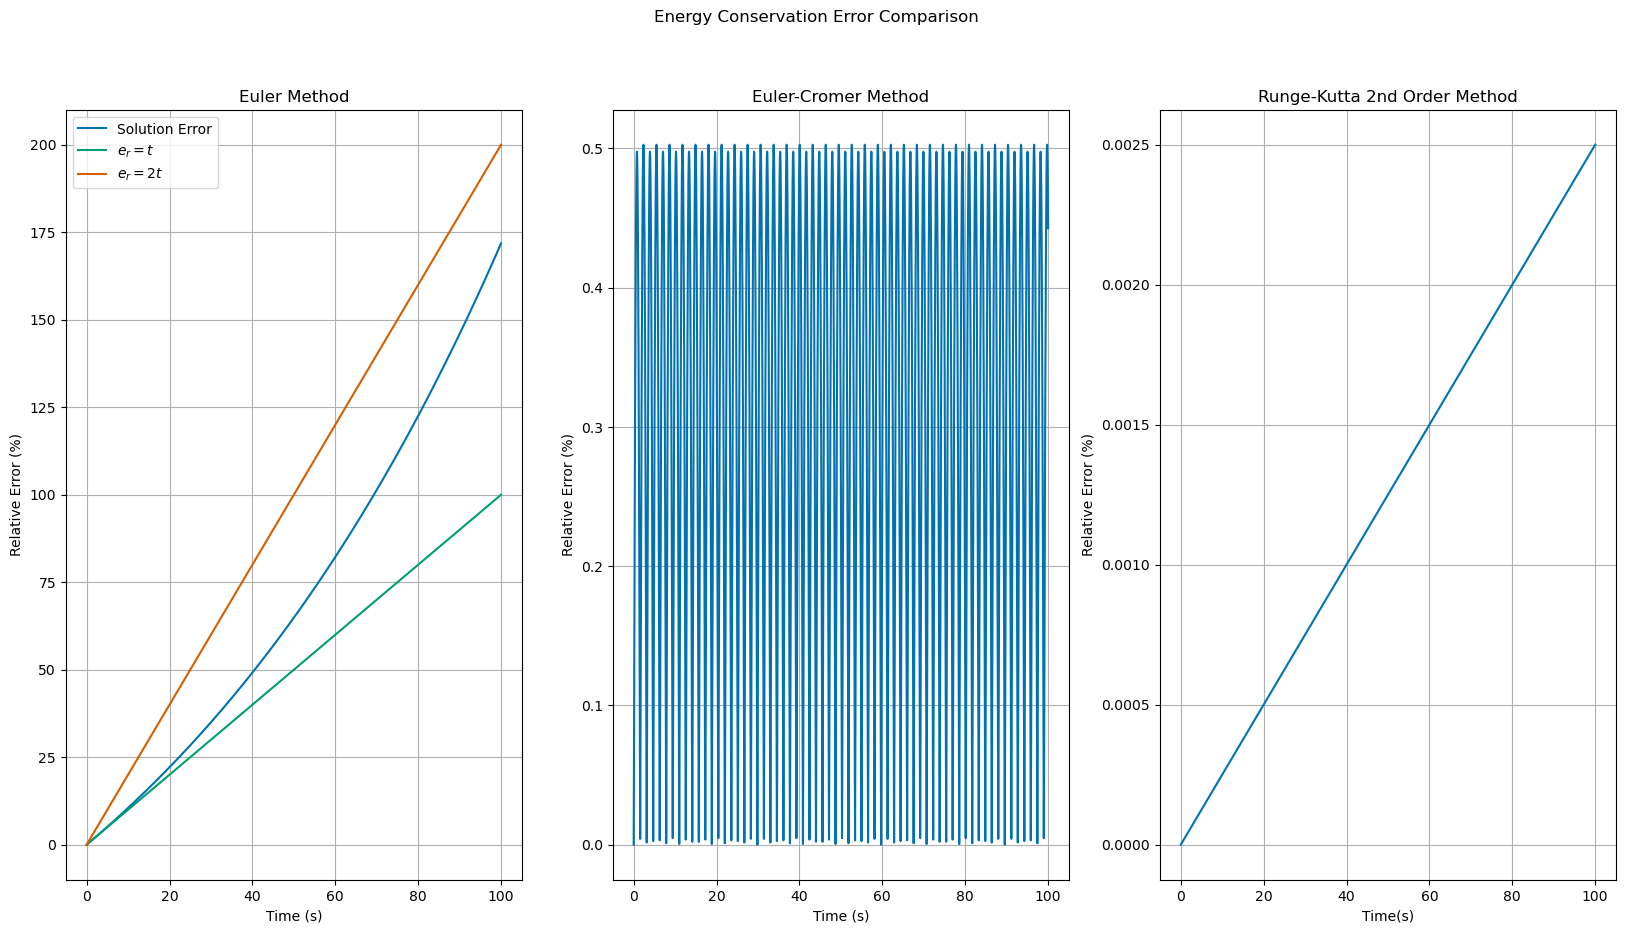

In [59]:
fig, ax = plt.subplots(1,3,figsize=(20,10))
plt.suptitle("Energy Conservation Error Comparison")

ax[0].plot(eulerdf['t'],RelativeError(euler_e,exact_energy),label="Solution Error")
ax[0].plot(eulerdf['t'],eulerdf['t'],label=r"$e_r = t$")
ax[0].plot(eulerdf['t'],2*eulerdf['t'],label=r"$e_r = 2t$")
ax[0].set_title("Euler Method")
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Relative Error (%)")
ax[0].legend()
ax[0].grid()

ax[1].plot(euler_cromerdf['t'],RelativeError(e_cromer_e,exact_energy))
ax[1].set_title("Euler-Cromer Method")
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Relative Error (%)")
ax[1].grid()

ax[2].plot(r_k2df['t'],RelativeError(rk2_e,exact_energy))
ax[2].set_title("Runge-Kutta 2nd Order Method")
ax[2].set_xlabel("Time(s)")
ax[2].set_ylabel("Relative Error (%)")
ax[2].grid()
plt.show()

As expected, the Euler and Euler-Cromer methods look the same. The Runge-Kutta 2nd Order method, however, looks like it has an error of exactly $2.5\cdot10^{-5}t\%$, which is extremely good, about four orders of magnitude better than the other methods in terms of conservation of energy.

### 5e.
Look up `solve_ivp` in the `scipy` library and use it to solve the SHO. Compare the results to the previous methods. What integrator is `solve_ivp` using?

We look at [this](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html) page in the scipy library.

In [60]:
import scipy.integrate as scipy

Our time-span is of course, $[0,100]$ s, every $\frac{1}{100}$-th of a second.

For the solve_ivp function to produce something usable, we need to turn our equation, $\ddot{x} = -\omega^2 x$, into first order differential equations.

$$\dot{v} = \ddot{x} = -\omega^2x$$
$$\dot{x} = v$$
$$x(0) = 1\quad v(0) = 0$$


In [61]:

t_pts = np.arange(t0,tf,dt)
t_range = (t0,tf)
init_conds = [1,0]
def eqs(t,curr,omega=1): #we need t as the first parameter for solve_ivp
    x,v = curr #gets the current values of x and v.
    return [v,-omega**2*x]
res = scipy.solve_ivp(eqs, (0,100), init_conds, t_eval=t_pts)

We plot this solution, it should look very similar to the others.

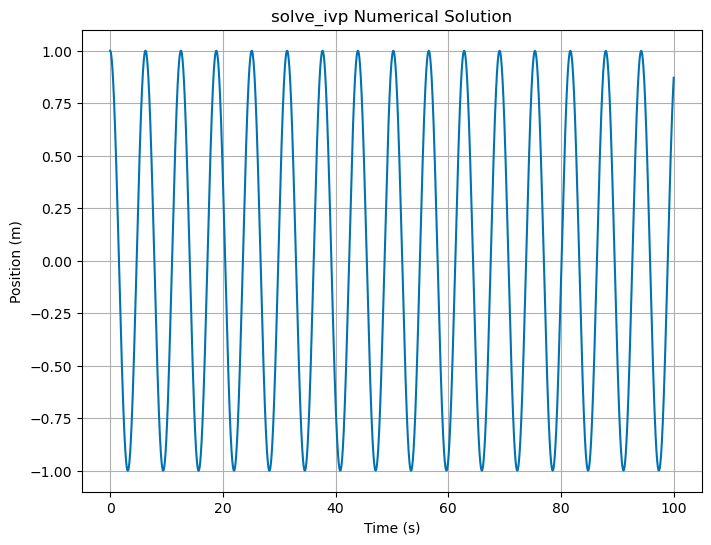

In [62]:
plt.figure(figsize=(8,6))
plt.plot(res.t, res.y[0,:]) #y[0] is the positon array, and y[1] is the velocity array.
plt.title("solve_ivp Numerical Solution") #Now lets see scipy's business card. 
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.grid()
plt.show()

Looks good, we check now the error in energy conservation.

In [63]:
ivp_k, ivp_u = KineticEnergy(res.y[1,:]), PotentialEnergy(res.y[0,:],omega=omega)
ivp_e = TotEnergy(ivp_k,ivp_u)

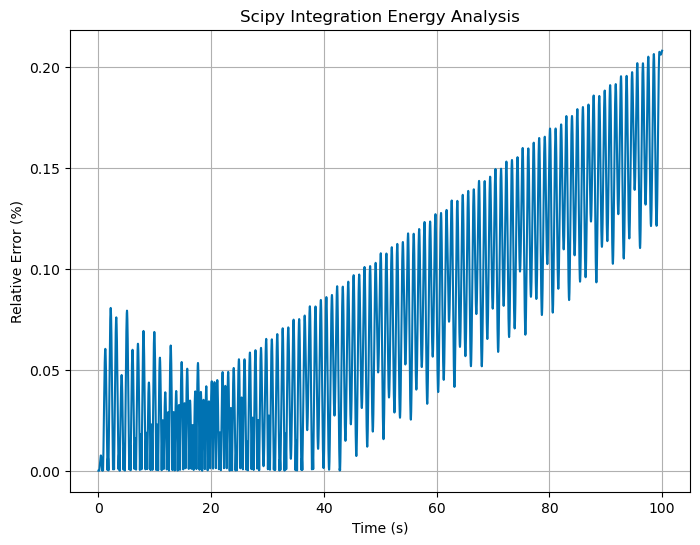

In [64]:
fig, ax = plt.subplots(1,1,figsize=(8,6))
ax.set_title("Scipy Integration Energy Analysis")
ax.plot(t_pts,RelativeError(ivp_e,exact_energy))
ax.set_xlabel('Time (s)')
ax.set_ylabel('Relative Error (%)')
ax.grid()
plt.show()

A pretty surprising result, actually. I was thinking it was going to be on the same level as the Runge-Kutta 2nd Order numerical approximation, but its acutally less accurate over time than the Euler-Cromer numerical integration. That might be due to the linearization, and the fact that there is a minute amount of info lost there?

### 5f.
Using the integrator of your choosing, find numerical solutions for a given choice of initial conditions for each of the examples in exercise 5. Plot the phase diagram and the numerically computed trajectory on the phase diagram. See the example below for the simple harmonic oscillator.

We take the EoM of the following:

Damped Harmonic Oscillation;
$$ \ddot{x} = -\frac{k}{m}x - \frac{b}{m}\dot{x} $$
Pendulum Oscillation;
$$ \ddot{\theta} = -\frac{g}{L}\sin(\theta) $$
Damped Pendulum Oscillation;
$$ \ddot{\theta} = -\frac{g}{L}\sin(\theta) - \frac{b}{mL}\dot{\theta}$$


Now, we use Runge-Kutta to integrate these, after turning them into first-order ODEs. We also choose all constants such that all coefficients are unity or negative unity.

Damped Harmonic Oscillation;
$$\dot{v} = \ddot{x} = -x - v$$
$$\dot{x} = v$$
Pendulum Oscillation;
$$\dot{\omega} = \ddot{\theta} = -\sin(\theta)$$
$$\dot{\theta} = \omega$$
Damped Pendulum Oscillation;
$$\dot{\omega} = \ddot{\theta} = -\sin(\theta) - \omega$$
$$\dot{\theta} = \omega$$

And we will use the Runge-Kutta, 2nd-order integration method, by adapting our previous function for such.

In [65]:
def SHO_acc(x,v):
    return -x

def DHO_acc(x,v):
    return -x-v

def PO_acc(theta,omega):
    return -np.sin(theta) 
    #have to use np.sin() here because math.sin() does not work with iterables.

def DPO_acc(theta,omega):
    return -np.sin(theta) - omega

#define our acceleration functions that we will call in our RK2O integration function

def RK2O_gen(x_0,v_0,t_0,tf,dt,acc_func=SHO_acc):
    #here, x,v are arbitrary parameters, we simply need a name for them.
    t = np.arange(t_0, tf, dt)
    x = np.zeros(t.shape)
    v = np.zeros(t.shape)
    x[0], v[0] = x_0,v_0
    
    for i in range(1,len(t)):
        x_prev = x[i-1]
        v_prev = v[i-1]

        k_1x = v_prev * dt
        k_1v = dt * acc_func(x_prev,v_prev)

        k_2x = dt * (v_prev + k_1v)
        k_2v = dt * (acc_func(x_prev+k_1x,v_prev+k_1v))

        x[i] = x_prev + 0.5 * (k_1x+k_2x)
        v[i] = v_prev + 0.5 * (k_1v+k_2v)
    return t,x,v

In [66]:
#we choose initial conditions
DHO_x_0 = 1
DHO_v_0 = 0

PO_theta_0 = pi/3
PO_omega_0 = 0

DPO_theta_0 = pi/3
DPO_omega_0 = 0

t0 = 0  # Start time
tf = 100  # End time
N = 10000  # Number of time steps
dt = (tf-t0)/N  # Time step

#call our function and add the results to their own dataframes
t, x, v = RK2O_gen(DHO_x_0, DHO_v_0, t0, tf, dt, DHO_acc)
DHO_df = pd.DataFrame({'t': t, 'x': x, 'v': v})

t,theta,omega = RK2O_gen(PO_theta_0,PO_omega_0,t0,tf,dt, PO_acc)
PO_df = pd.DataFrame({'t':t,'theta':theta,'omega':omega})

t,theta,omega = RK2O_gen(DPO_theta_0,DPO_omega_0,t0,tf,dt, DPO_acc)
DPO_df = pd.DataFrame({'t':t,'theta':theta,'omega':omega})


We now define our general phase space function, adapted from problem 4.

In [67]:
def Generate_Phase_Space_gen(x_lim,v_lim,grid_size,acc_func=SHO_acc):
    X_space = np.linspace(x_lim[0],x_lim[1], grid_size)
    V_space = np.linspace(v_lim[0], v_lim[1], grid_size)
# intitalize our axes
    X,V = np.meshgrid(X_space,V_space)
# combine axes
    dX,dV = V, acc_func(X,V)
# calculate change in axes values
    return X,V,dX,dV

xlim = (-2.5,2.5)
vlim = (-2.5,2.5)
g_size = 20

x,v,dx,dv = Generate_Phase_Space_gen(xlim,vlim,g_size,acc_func=DHO_acc)

thlim = (-2.5,2.5)
omegalim = (-2.5,2.5)

th_1,omega_1, dth_1, domega_1 = Generate_Phase_Space_gen(thlim,omegalim,g_size,acc_func=PO_acc)

th_2,omega_2, dth_2, domega_2 = Generate_Phase_Space_gen(thlim,omegalim,g_size,acc_func=DPO_acc)

#call our function for each plot

We have our data values, now all that is left is to plot them.

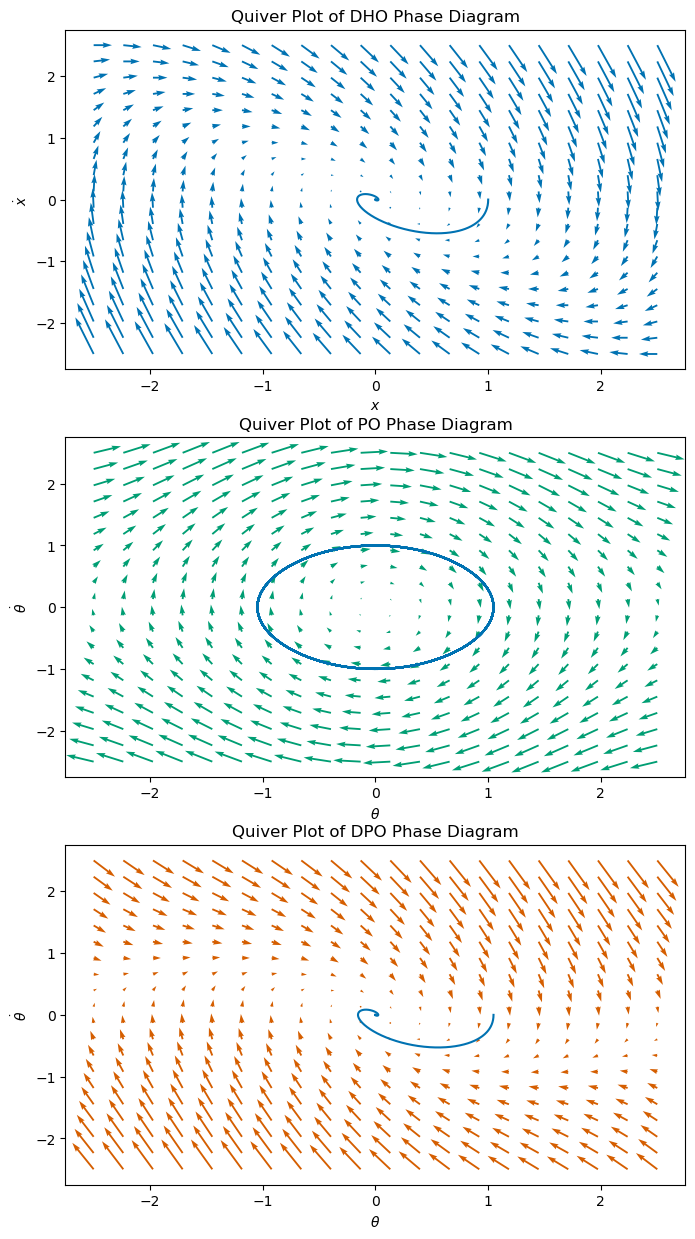

In [68]:
fig, ax = plt.subplots(3, 1, figsize=(8, 15)) 

ax[0].quiver(x, v, dx, dv, color='C0')
ax[0].set_title('Quiver Plot of DHO Phase Diagram')
ax[0].set_xlabel(r'$x$')
ax[0].set_ylabel(r'$\dot{x}$')
ax[0].plot(DHO_df['x'],DHO_df['v'])

ax[1].quiver(th_1,omega_1,dth_1,domega_1, color='C1')
ax[1].set_title('Quiver Plot of PO Phase Diagram')
ax[1].set_xlabel(r'$\theta$')
ax[1].set_ylabel(r'$\dot{\theta}$')
ax[1].plot(PO_df['theta'],PO_df['omega'])

ax[2].quiver(th_2,omega_2,dth_2,domega_2, color='C2')
ax[2].set_title('Quiver Plot of DPO Phase Diagram')
ax[2].set_xlabel(r'$\theta$')
ax[2].set_ylabel(r'$\dot{\theta}$')
ax[2].plot(DPO_df['theta'],DPO_df['omega'])

plt.show()